<a href="https://colab.research.google.com/github/dea43325108-crypto/Visi-Komputer_Dea-Cantika/blob/main/Jobsheet_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum D1 – Regresi dari Citra Sintetis (Prediksi Radius Lingkaran)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras import layers, models

# Generator 1 sample
def make_sample(img_size=64, min_r=5, max_r=20):
    r = np.random.randint(min_r, max_r + 1) # radius acak
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r) # center-x
    cy = np.random.randint(r, img_size - r) # center-y
    cv2.circle(img, (cx, cy), r, (255,), -1) # lingkaran putih terisi
    img = (img / 255.0).astype(np.float32)
    # 3-channel biar kompatibel CNN
    img3 = np.stack([img, img, img], axis=-1)
    return img3, float(r), (cx, cy)

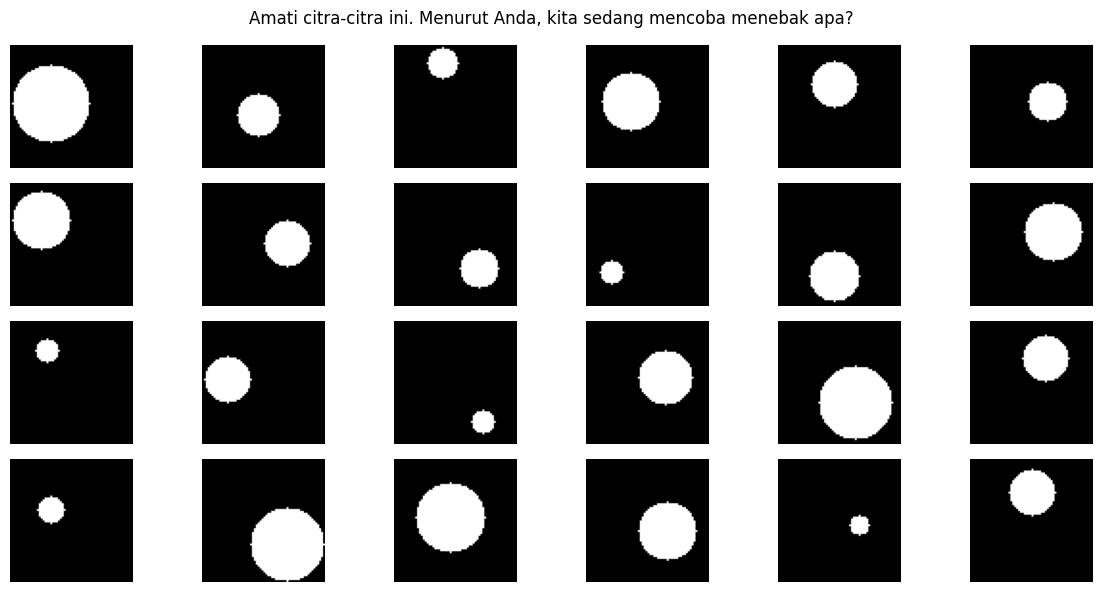

In [ ]:
# Buat 24 contoh untuk visualisasi
N_show = 24
samples = [make_sample() for _ in range(N_show)]
imgs = [s[0] for s in samples]
rads = [s[1] for s in samples]
centers = [s[2] for s in samples]

# Grid gambar tanpa label:
cols = 6
rows = N_show // cols
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.axis('off')
plt.suptitle("Amati citra-citra ini. Menurut Anda, kita sedang mencoba menebak apa?")
plt.tight_layout()
plt.show()

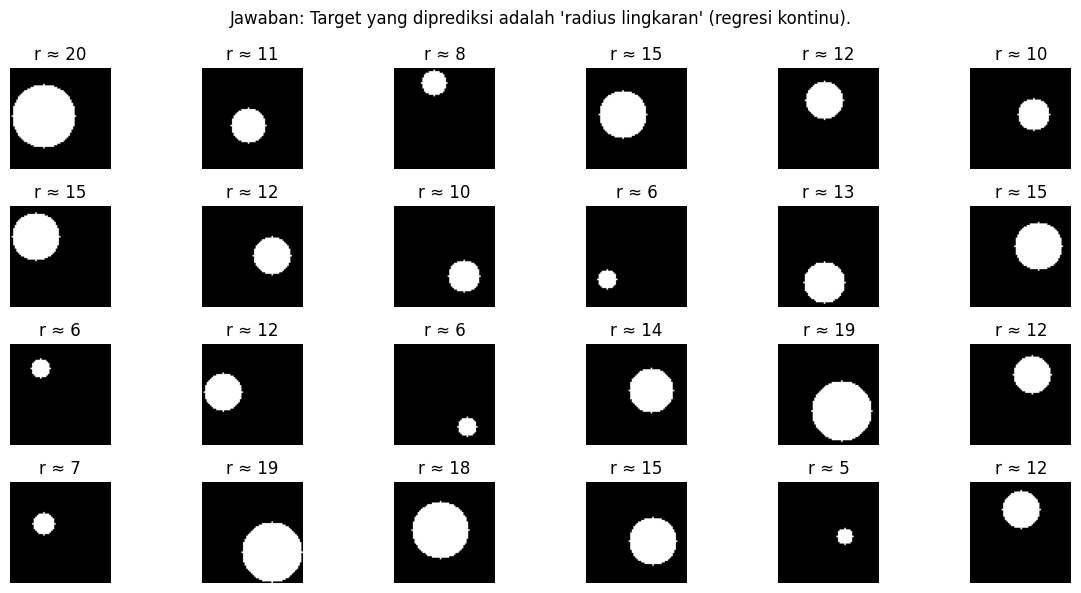

In [ ]:
# Tampilkan kembali, sekarang tampilkan radius (label) di judul tiap subplot
plt.figure(figsize=(12, 6))
for i in range(N_show):
    plt.subplot(rows, cols, i+1)
    plt.imshow(imgs[i].squeeze(), cmap='gray')
    plt.title(f"r ≈ {int(rads[i])}")
    plt.axis('off')
plt.suptitle("Jawaban: Target yang diprediksi adalah 'radius lingkaran' (regresi kontinu).")
plt.tight_layout()
plt.show()

In [ ]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # output regresi
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                    epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred) ** 2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step
MAE=0.971 | RMSE=1.192 | R²=0.928


In [ ]:
# Siapkan dataset lebih besar untuk training
N = 3000
X, y, C = zip(*[make_sample() for _ in range(N)])
X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.float32)

Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)

# Model CNN sederhana
model = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1) # output regresi
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
history = model.fit(Xtr, ytr, validation_data=(Xte, yte),
                    epochs=12, batch_size=64, verbose=0)

# Evaluasi
y_pred = model.predict(Xte).ravel()
mae = mean_absolute_error(yte, y_pred)
rmse = float(np.sqrt(np.mean((yte - y_pred) ** 2)))
r2 = r2_score(yte, y_pred)
print(f"MAE={mae:.3f} | RMSE={rmse:.3f} | R²={r2:.3f}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
MAE=0.914 | RMSE=1.127 | R²=0.936


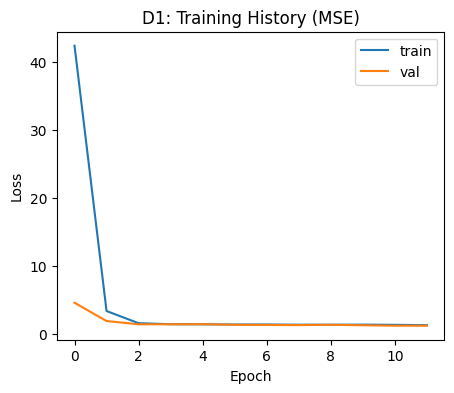

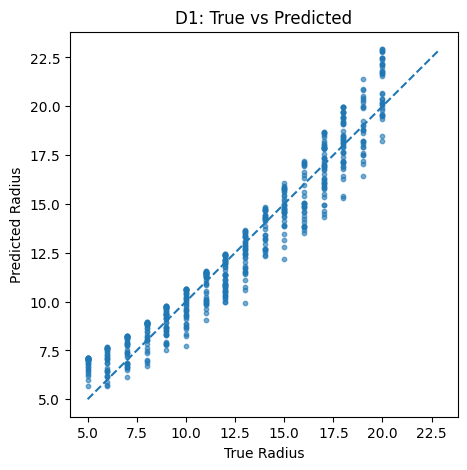

In [ ]:
# Plot loss
plt.figure(figsize=(5,4))
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("D1: Training History (MSE)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()

# Scatter True vs Pred
plt.figure(figsize=(5,5))
plt.scatter(yte, y_pred, s=10, alpha=0.6)
lims = [min(yte.min(), y_pred.min()), max(yte.max(), y_pred.max())]
plt.plot(lims, lims, '--')
plt.xlabel("True Radius"); plt.ylabel("Predicted Radius")
plt.title("D1: True vs Predicted")
plt.show()

*Tantangan Mini (Opsional untuk Mahasiswa)*

•	Ubah rentang radius (mis. 8–28) dan lihat dampaknya ke MAE/RMSE/R²

•	Tambahkan noise (blur, noise Gaussian) ke citra

In [ ]:
import numpy as np
import cv2

# Modifikasi fungsi dari praktikum awal
def make_sample_modified(img_size=64, min_r=8, max_r=28): # 1. Ubah rentang radius ke 8-28
    r = np.random.randint(min_r, max_r + 1)
    img = np.zeros((img_size, img_size), dtype=np.uint8)
    cx = np.random.randint(r, img_size - r)
    cy = np.random.randint(r, img_size - r)
    cv2.circle(img, (cx, cy), r, (255,), -1)

    # 2. Tambahkan noise (Contoh: Gaussian Blur) agar tepi lingkaran tidak terlalu tajam
    img = cv2.GaussianBlur(img, (5, 5), 0)

    img = (img / 255.0).astype(np.float32)
    img3 = np.stack([img, img, img], axis=-1)

    # Return dipisah agar mudah diambil untuk target multi-output
    return img3, float(r), float(cx), float(cy)

•	Jadikan tugas multi-output: prediksikan [r,cx,cy][r, c_x, c_y][r,cx,cy] sekaligus; metrik evaluasi

In [ ]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Siapkan dataset baru dengan target multi-output
N = 3000
# Ambil gambar (X) dan ketiga targetnya (r, cx, cy)
X, y_r, y_cx, y_cy = zip(*[make_sample_modified() for _ in range(N)])
X = np.array(X, dtype=np.float32)

# Gabungkan target menjadi array 3 kolom: [r, cx, cy]
y_multi = np.column_stack((y_r, y_cx, y_cy)).astype(np.float32)

# Split dataset
Xtr, Xte, ytr, yte = train_test_split(X, y_multi, test_size=0.2, random_state=42)

# Modifikasi Model CNN untuk Multi-Output
model_multi = models.Sequential([
    layers.Input((64, 64, 3)),
    layers.Conv2D(32, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'), layers.MaxPooling2D(),
    layers.Conv2D(128, 3, activation='relu'),
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3) # <--- PERUBAHAN UTAMA: Output 3 neuron untuk memprediksi [r, cx, cy] sekaligus
])

# Menjawab pertanyaan "metrik evaluasi apa yang cocok?"
# Untuk regresi multi-variabel kontinu, MSE (Mean Squared Error) sebagai loss
# dan MAE (Mean Absolute Error) sebagai metrik evaluasi adalah pilihan yang tepat.
model_multi.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Latih model
history_multi = model_multi.fit(Xtr, ytr, validation_data=(Xte, yte), epochs=12, batch_size=64, verbose=1)

Epoch 1/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 257ms/step - loss: 458.4824 - mae: 17.1886 - val_loss: 167.5921 - val_mae: 8.8167
Epoch 2/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 245ms/step - loss: 99.8153 - mae: 6.8694 - val_loss: 63.3534 - val_mae: 6.2117
Epoch 3/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 251ms/step - loss: 55.8025 - mae: 5.5041 - val_loss: 51.3246 - val_mae: 5.0502
Epoch 4/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 261ms/step - loss: 50.2379 - mae: 4.8239 - val_loss: 48.5654 - val_mae: 4.7261
Epoch 5/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 231ms/step - loss: 48.2185 - mae: 4.6852 - val_loss: 46.2223 - val_mae: 4.6107
Epoch 6/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - loss: 46.2810 - mae: 4.5640 - val_loss: 44.3347 - val_mae: 4.4986
Epoch 7/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 11s 238ms/step - loss: 45.1499 - mae: 4.5269 - val_loss: 43.6206 - val_mae: 4.4846
Epoch 8/12
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 244ms/step - loss: 43.4788 - mae: 4.4354 - val_loss: 41.6304 - val_mae: 4.4129
Epoch 9/12
38/38 ━━━━━━━━━━━━━━

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
MAE Radius (r)   : 1.056
MAE Center X (cx): 5.502
MAE Center Y (cy): 5.764


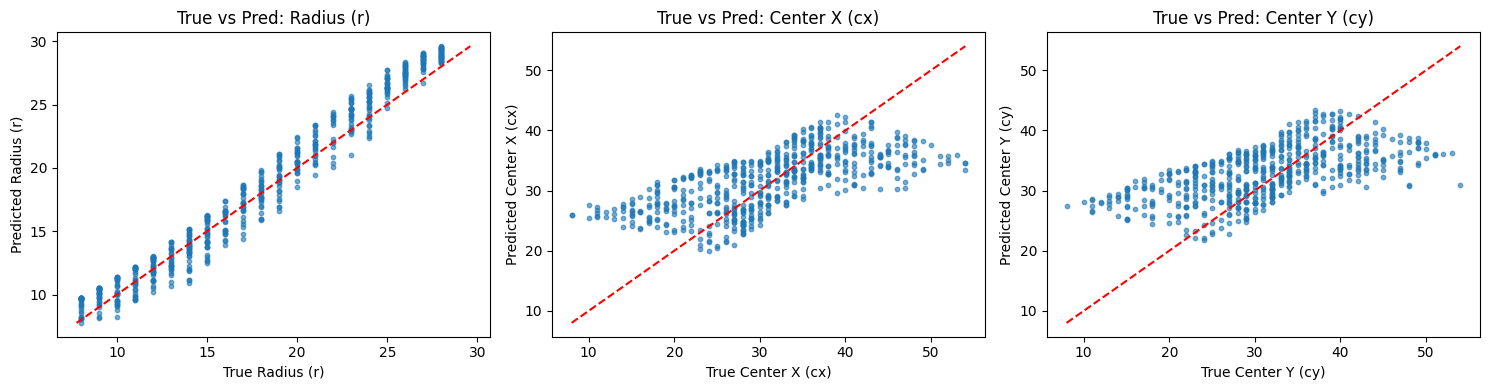

In [ ]:
# 1. Prediksi data pengujian
y_pred_multi = model_multi.predict(Xte)

# 2. Hitung MAE untuk masing-masing target (r, cx, cy)
mae_r = mean_absolute_error(yte[:, 0], y_pred_multi[:, 0])
mae_cx = mean_absolute_error(yte[:, 1], y_pred_multi[:, 1])
mae_cy = mean_absolute_error(yte[:, 2], y_pred_multi[:, 2])

print(f"MAE Radius (r)   : {mae_r:.3f}")
print(f"MAE Center X (cx): {mae_cx:.3f}")
print(f"MAE Center Y (cy): {mae_cy:.3f}")

# 3. Visualisasi Scatter Plot True vs Predicted untuk r, cx, dan cy
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
targets = ['Radius (r)', 'Center X (cx)', 'Center Y (cy)']

for i in range(3):
    axes[i].scatter(yte[:, i], y_pred_multi[:, i], s=10, alpha=0.6)
    lims = [min(yte[:, i].min(), y_pred_multi[:, i].min()), max(yte[:, i].max(), y_pred_multi[:, i].max())]
    axes[i].plot(lims, lims, 'r--')
    axes[i].set_xlabel(f"True {targets[i]}")
    axes[i].set_ylabel(f"Predicted {targets[i]}")
    axes[i].set_title(f"True vs Pred: {targets[i]}")

plt.tight_layout()
plt.show()

# Praktikum D2 – Menebak Umur Manusia dari Foto Wajah (UTKFace)

**Langkah 2 — Mengunggah kaggle.json ke Colab**

In [1]:
# Jalankan ini di awal notebook
from google.colab import files
files.upload()  # pilih file kaggle.json dari komputer Anda

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"deacantika","key":"4cd0c17d084ff4be4bcfaf6571a586ce"}'}

In [2]:
import os, shutil
if os.path.exists("kaggle.json"):
    os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
    shutil.copy("kaggle.json", os.path.expanduser("~/.kaggle/kaggle.json"))
    os.chmod(os.path.expanduser("~/.kaggle/kaggle.json"), 0o600)
    !pip -q install kaggle
    print("✅ Kaggle API siap digunakan.")
else:
    print("❌ kaggle.json belum ditemukan. Upload terlebih dahulu.")

✅ Kaggle API siap digunakan.


**Langkah 3 — Mengunduh Dataset UTKFace dari Kaggle**

In [3]:
# Unduh dataset UTKFace (sekali saja)
!kaggle datasets download -d jangedoo/utkface-new -p /content -q
!unzip -q /content/utkface-new.zip -d /content/utk
print("✅ Dataset UTKFace berhasil diekstrak.")

Dataset URL: https://www.kaggle.com/datasets/jangedoo/utkface-new
License(s): copyright-authors
✅ Dataset UTKFace berhasil diekstrak.


**Langkah 4 — Menampilkan Contoh Gambar Dataset**

Total gambar ditemukan: 23708


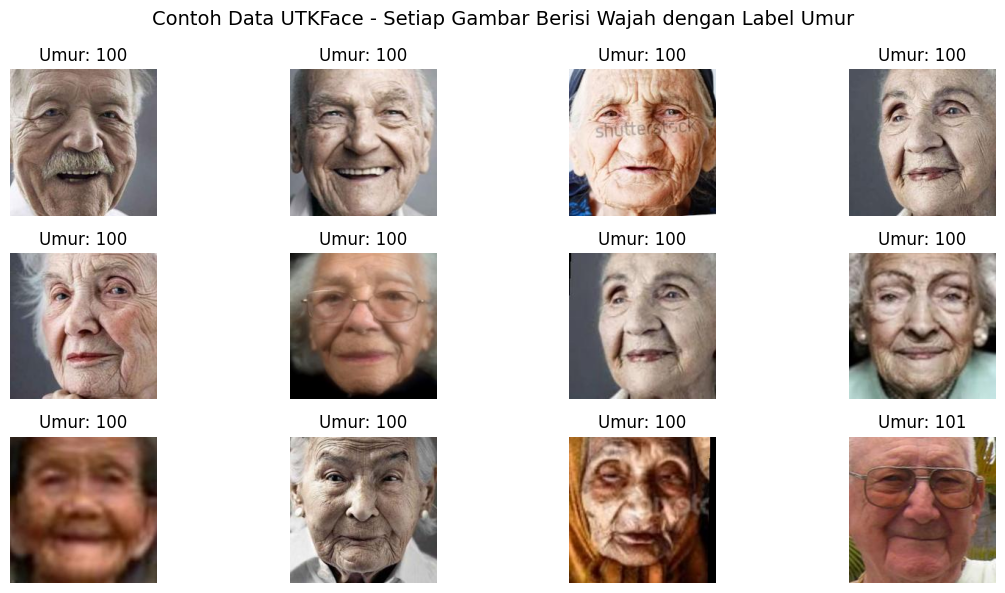

In [4]:
import matplotlib.pyplot as plt
import os, glob
from PIL import Image

# Ambil 12 gambar acak dari dataset
files = glob.glob("/content/utk/UTKFace/*.jpg")
files = sorted(files)
print(f"Total gambar ditemukan: {len(files)}")

plt.figure(figsize=(12, 6))
for i, f in enumerate(files[:12]):
    # Ambil umur dari nama file
    age = int(os.path.basename(f).split("_")[0])
    img = Image.open(f)
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"Umur: {age}")
    plt.axis("off")
plt.suptitle("Contoh Data UTKFace - Setiap Gambar Berisi Wajah dengan Label Umur", fontsize=14)
plt.tight_layout()
plt.show()

**Langkah 5 — Siapkan Dataset untuk Model**

In [5]:
import tensorflow as tf
import numpy as np
from sklearn.model_selection import train_test_split

def parse_age_from_name(fp):
    return int(os.path.basename(fp).split('_')[0])

ages = np.array([parse_age_from_name(f) for f in files], dtype=np.float32)
train_files, test_files, y_train, y_test = train_test_split(
    files, ages, test_size=0.2, random_state=42
)

IMG_SIZE = 160
def load_img(fp, label):
    img = tf.io.read_file(fp)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img / 255.0, label

train_ds = tf.data.Dataset.from_tensor_slices((train_files,
y_train)).map(load_img).batch(64)
test_ds = tf.data.Dataset.from_tensor_slices((test_files,
y_test)).map(load_img).batch(64)

print("✅ Dataset siap dilatih.")

✅ Dataset siap dilatih.


**Langkah 6 — Membangun Model dengan Transfer Learning**

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Gunakan GPU jika tersedia
print("Hardware:", "GPU" if tf.config.list_physical_devices('GPU') else
"CPU")

# Buat arsitektur model
base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    weights='imagenet'
)
base_model.trainable = False  # tahap awal: freeze backbone

# Tambahkan head regresi
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
x = layers.Dense(128, activation='relu')(x)
outputs = layers.Dense(1)(x)  # output tunggal: umur
model = tf.keras.Model(inputs, outputs)

# Kompilasi model
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='mse', metrics=['mae'])

model.summary()

Hardware: CPU
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Langkah 7 — Melatih Model (Tahap 1 – Frozen)**

Epoch 1/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 486s 2s/step - loss: 222.9565 - mae: 11.0953 - val_loss: 158.4535 - val_mae: 9.5802 - learning_rate: 0.0010
Epoch 2/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 466s 2s/step - loss: 151.8351 - mae: 9.1757 - val_loss: 148.7142 - val_mae: 9.1986 - learning_rate: 0.0010
Epoch 3/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 475s 2s/step - loss: 143.5489 - mae: 8.8853 - val_loss: 143.5756 - val_mae: 8.9857 - learning_rate: 0.0010
Epoch 4/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 539s 2s/step - loss: 139.1325 - mae: 8.7009 - val_loss: 140.0772 - val_mae: 8.8128 - learning_rate: 0.0010
Epoch 5/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 513s 2s/step - loss: 136.2370 - mae: 8.6106 - val_loss: 140.5410 - val_mae: 8.8623 - learning_rate: 0.0010
Epoch 6/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 524s 2s/step - loss: 135.7632 - mae: 8.5835 - val_loss: 138.7327 - val_mae: 8.7699 - learning_rate: 0.0010
Epoch 7/10
297/297 ━━━━━━━━━━━━━━━━━━━━ 525s 2s/step - loss: 131.7634 - mae: 8.4367 - val_loss: 136.3779 - val_mae: 8

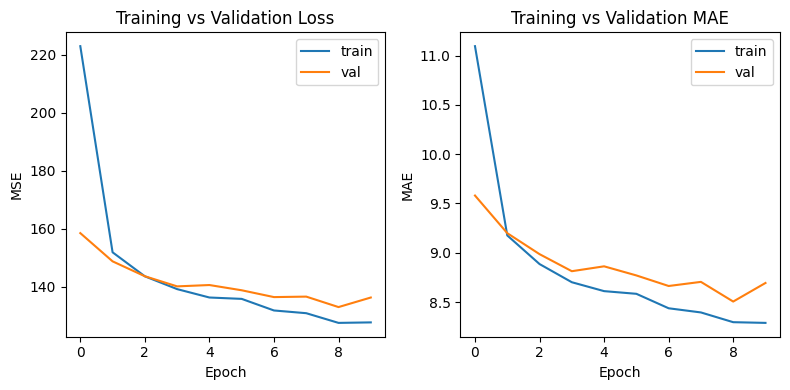

In [8]:
# Callback untuk pelatihan yang lebih stabil
cb = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True,
monitor='val_loss'),
    tf.keras.callbacks.ReduceLROnPlateau(patience=2, factor=0.5, min_lr=1e-5, monitor='val_loss')
]

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10,
    callbacks=cb,
    verbose=1
)

# Visualisasi perubahan loss dan MAE selama pelatihan:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MSE'); plt.title('Training vs Validation Loss')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['mae'], label='train')
plt.plot(history.history['val_mae'], label='val')
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.tight_layout()
plt.show()